**TASK 5**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import os
from google.colab import files

# 1. Clear memory and set seeds
tf.keras.backend.clear_session()

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# 2. Load Data (CIFAR-10)
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# NOTE: We do NOT divide by 255.0 here. VGG16's preprocess_input expects 0-255 inputs!
x_train_cifar = cifar_x_train.astype('float32')
x_test_cifar = cifar_x_test.astype('float32')
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)
y_test_cifar = tf.keras.utils.to_categorical(cifar_y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


PROBLEM 1

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Parameter Counts ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 96, 96, 3) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Trainable Parameters: 133898
Frozen Parameters: 14714688

Training Frozen Model (10 Epochs)...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.6614 - loss: 1.2924 - val_accuracy: 0.7890 - val_loss: 0.6044
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.7709 - loss: 0.6815 - val_accuracy: 0.8122 - val_loss: 0.5376
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.8011 - loss: 0.5865 - val_accuracy: 0.8252 - val_loss: 0.5047
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.8184 - loss: 0.5327 - val_accuracy: 0.8318 - val_loss: 0.4877
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.8300 - loss: 0.4896 - val_accuracy: 0.8328 - val_loss: 0.4855
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.8404 - loss: 0.4623 - val_accuracy: 0.8362 - val_loss: 0.4823
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.8441 - loss: 0.4399 - val_accuracy: 0.8400 - val_l

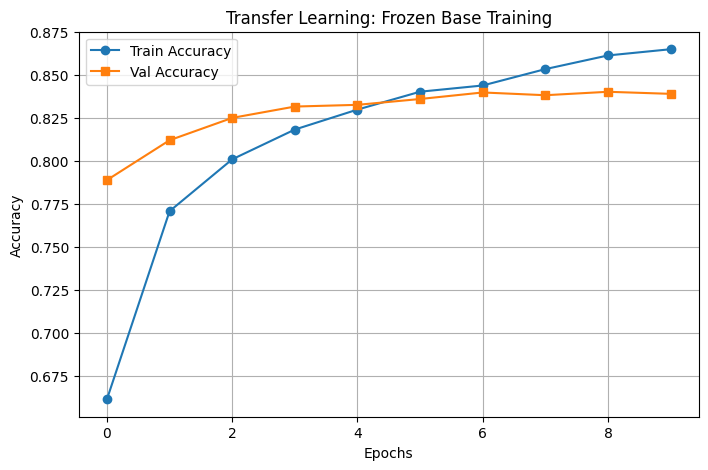

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Epoch 10 Validation Accuracy: 0.8392


In [2]:
set_seeds()

# 1. Load VGG16 base
vgg_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
vgg_base.trainable = False # Freeze all layers

# 2. Build Model Pipeline
inputs = layers.Input(shape=(32, 32, 3))
# Upsample to 96x96
x = layers.Resizing(96, 96)(inputs)
# Apply VGG16 specific preprocessing (e.g., RGB to BGR, zero-centering)
x = tf.keras.applications.vgg16.preprocess_input(x)
# Pass through frozen base
x = vgg_base(x, training=False)

# Custom Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_frozen = models.Model(inputs, outputs)

# 3. Print parameter counts
print("--- Parameter Counts ---")
model_frozen.summary()
trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model_frozen.trainable_weights])
frozen_count = np.sum([tf.keras.backend.count_params(w) for w in model_frozen.non_trainable_weights])
print(f"Trainable Parameters: {trainable_count}")
print(f"Frozen Parameters: {frozen_count}")

# 4. Train
model_frozen.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTraining Frozen Model (10 Epochs)...")
hist_frozen = model_frozen.fit(x_train_cifar, y_train_cifar, epochs=10,
                               batch_size=128, validation_split=0.1, verbose=1)

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(hist_frozen.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(hist_frozen.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Transfer Learning: Frozen Base Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('tl_frozen.png')
plt.show()
files.download('tl_frozen.png')

print(f"Epoch 10 Validation Accuracy: {hist_frozen.history['val_accuracy'][-1]:.4f}")

PROBLEM 2

Fine-tuning top 4 layers (10 more epochs)...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - accuracy: 0.8870 - loss: 0.3199 - val_accuracy: 0.8660 - val_loss: 0.4326
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.9152 - loss: 0.2398 - val_accuracy: 0.8756 - val_loss: 0.4210
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.9292 - loss: 0.1972 - val_accuracy: 0.8832 - val_loss: 0.4012
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.9415 - loss: 0.1612 - val_accuracy: 0.8860 - val_loss: 0.3918
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.9519 - loss: 0.1350 - val_accuracy: 0.8924 - val_loss: 0.3933
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.9596 - loss: 0.1140 - val_accuracy: 0.8940 - val_loss: 0.3986
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.9666 - loss: 0.0951 - val_accuracy: 0.8978 - val_loss: 0.4021
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━

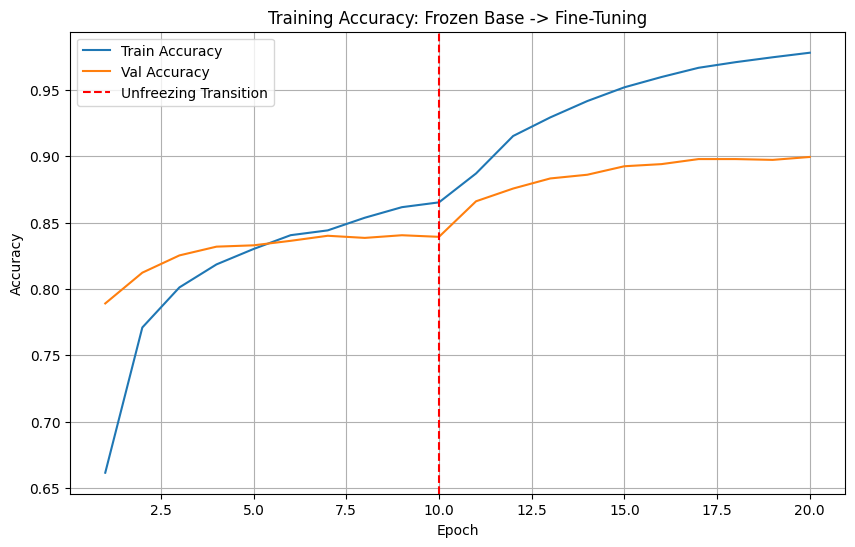

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best Validation Accuracy achieved: 0.8994 at fine-tuning epoch 10


In [3]:
set_seeds()

# 1. Unfreeze the base model
vgg_base.trainable = True

# 2. Re-freeze all layers EXCEPT the last 4
# VGG16 has blocks, the last block is block5 (conv1, conv2, conv3, pool).
# We will leave the last 4 layers trainable.
for layer in vgg_base.layers[:-4]:
    layer.trainable = False

# Must recompile after changing trainable property!
model_frozen.compile(optimizer=optimizers.Adam(learning_rate=1e-5), # 100x smaller
                     loss='categorical_crossentropy', metrics=['accuracy'])

print("Fine-tuning top 4 layers (10 more epochs)...")
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

hist_finetune = model_frozen.fit(x_train_cifar, y_train_cifar, epochs=10,
                                 batch_size=128, validation_split=0.1,
                                 callbacks=[early_stop], verbose=1)

# 3. Combine Histories for plotting
acc_combined = hist_frozen.history['accuracy'] + hist_finetune.history['accuracy']
val_acc_combined = hist_frozen.history['val_accuracy'] + hist_finetune.history['val_accuracy']
total_epochs = range(1, len(acc_combined) + 1)

plt.figure(figsize=(10, 6))
plt.plot(total_epochs, acc_combined, label='Train Accuracy')
plt.plot(total_epochs, val_acc_combined, label='Val Accuracy')
plt.axvline(x=10, color='red', linestyle='--', label='Unfreezing Transition')
plt.title('Training Accuracy: Frozen Base -> Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('tl_finetuned.png')
plt.show()
files.download('tl_finetuned.png')

best_ft_epoch = np.argmax(hist_finetune.history['val_accuracy']) + 1
best_ft_val = np.max(hist_finetune.history['val_accuracy'])
print(f"Best Validation Accuracy achieved: {best_ft_val:.4f} at fine-tuning epoch {best_ft_epoch}")

PROBLEM 3

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import pandas as pd
import numpy as np
import random
import os

# 1. Clear session and set seeds
tf.keras.backend.clear_session()

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# 2. Load Raw Data
print("Loading CIFAR-10 data...")
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()
x_train_cifar = cifar_x_train.astype('float32')
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)

# 3. HIGH-SPEED DATA PIPELINE (The fix for the 1-hour training time)
print("Building high-speed cached data pipeline. This will take ~30 seconds to initialize, then training will fly...")
def preprocess_for_vgg(image, label):
    # Resize and preprocess ONCE
    img_resized = tf.image.resize(image, (96, 96))
    img_preprocessed = tf.keras.applications.vgg16.preprocess_input(img_resized)
    return img_preprocessed, label

batch_size = 128
# Create validation split manually for the pipeline
val_split = int(0.1 * len(x_train_cifar))
x_val, y_val = x_train_cifar[:val_split], y_train_cifar[:val_split]
x_train, y_train = x_train_cifar[val_split:], y_train_cifar[val_split:]

# Build Train Pipeline
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess_for_vgg, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# Build Validation Pipeline
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess_for_vgg, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# 4. Execute Optimized Ablation Study
ablation_configs = {
    'Top 2 Layers': -2,
    'Top 8 Layers': -8,
    'All Layers': 0
}

ablation_results = []

for name, layer_idx in ablation_configs.items():
    print(f"\n=========================================")
    print(f"Running ablation: {name}")
    print(f"=========================================")

    # Rebuild fresh frozen model
    temp_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    temp_base.trainable = False

    # Notice we removed the Resizing and Preprocessing layers here because the Pipeline handles it now!
    inputs = layers.Input(shape=(96, 96, 3))
    x = temp_base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    temp_model = models.Model(inputs, outputs)

    # Pre-train head quickly (3 epochs)
    print("  -> Pre-training custom head...")
    temp_model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    temp_model.fit(train_ds, validation_data=val_ds, epochs=3, verbose=1)

    # Apply ablation unfreezing
    temp_base.trainable = True
    if layer_idx != 0:
        for layer in temp_base.layers[:layer_idx]:
            layer.trainable = False

    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in temp_model.trainable_weights])

    # Fine-tune (10 epochs)
    print(f"  -> Fine-tuning with {trainable_params:,} trainable parameters...")
    temp_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    history = temp_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

    val_acc = history.history['val_accuracy'][-1]
    train_acc = history.history['accuracy'][-1]
    is_overfit = "Yes" if (train_acc - val_acc) > 0.05 else "No"

    ablation_results.append({
        'Layers Unfrozen': name,
        'Trainable Params': f"{trainable_params:,}",
        'Val Accuracy': round(val_acc, 4),
        'Overfit (>5% gap)?': is_overfit
    })

# 5. Display Results
df_ablation = pd.DataFrame(ablation_results).set_index('Layers Unfrozen')
print("\n--- Optimized Ablation Study Results ---")
display(df_ablation)

Loading CIFAR-10 data...
Building high-speed cached data pipeline. This will take ~30 seconds to initialize, then training will fly...

Running ablation: Top 2 Layers
  -> Pre-training custom head...
Epoch 1/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 76s 205ms/step - accuracy: 0.6595 - loss: 1.3021 - val_accuracy: 0.7944 - val_loss: 0.6060
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.7696 - loss: 0.6850 - val_accuracy: 0.8156 - val_loss: 0.5448
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.7996 - loss: 0.5827 - val_accuracy: 0.8214 - val_loss: 0.5252
  -> Fine-tuning with 2,493,706 trainable parameters...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 84s 217ms/step - accuracy: 0.8314 - loss: 0.4950 - val_accuracy: 0.8386 - val_loss: 0.4832
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.8462 - loss: 0.4464 - val_accuracy: 0.8450 - val_loss: 0.4628
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.8599 - loss: 0.4067 - v

PROBLEM 4

Loading CIFAR-10 data...

[1/3] Training Baseline Scratch CNN...
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3771 - loss: 1.7048 - val_accuracy: 0.5488 - val_loss: 1.3079
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5111 - loss: 1.3570 - val_accuracy: 0.6030 - val_loss: 1.1190
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5634 - loss: 1.2300 - val_accuracy: 0.6158 - val_loss: 1.0890
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5935 - loss: 1.1466 - val_accuracy: 0.6488 - val_loss: 1.0130
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6144 - loss: 1.0937 - val_accuracy: 0.6688 - val_loss: 0.9723

[2/3] Training Pre-trained Base (Frozen)...
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 69s 162ms/step - accuracy: 0.6629 - loss: 1.3161 - val_accuracy: 0.7910 - val_loss: 0.6031
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.7713 - loss: 0.6833 - val_accuracy: 0.8110 - val_loss: 

,Test Accuracy,Total Trainable Params,Epochs to Best Val
Model,,,
Custom Scratch CNN,0.6591,"545,098",5
Pre-trained Base (Frozen),0.8248,"133,898",5
Pre-trained (Fine-Tuned),0.1000,"7,213,322",1


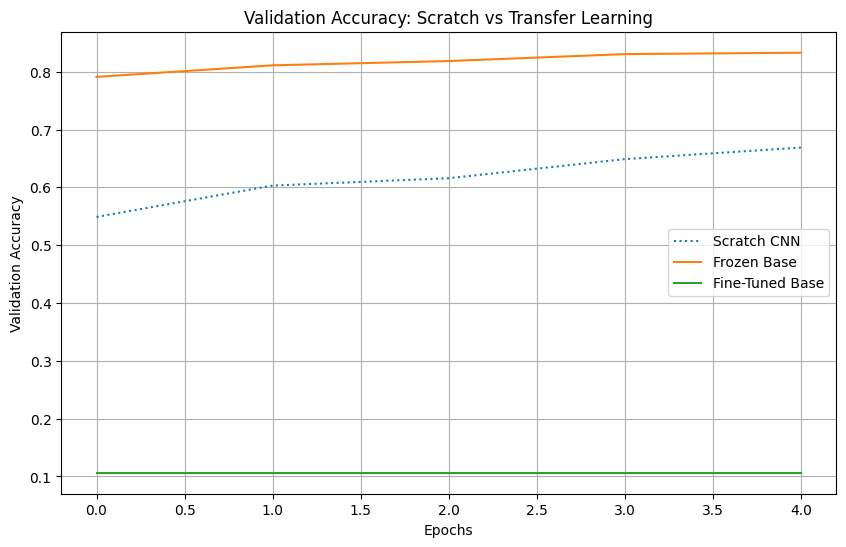

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, optimizers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import os
from google.colab import files

# 1. Define seeds locally so it never throws a NameError
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Clear any broken ghost models from memory and set seeds
tf.keras.backend.clear_session()
set_seeds()

# 2. Load and Prepare Data
print("Loading CIFAR-10 data...")
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()
x_train_cifar = cifar_x_train.astype('float32')
x_test_cifar = cifar_x_test.astype('float32')
y_train_cifar = tf.keras.utils.to_categorical(cifar_y_train, 10)
y_test_cifar = tf.keras.utils.to_categorical(cifar_y_test, 10)

# =========================================================
# REQUIRED MODEL 1: Scratch CNN (The Baseline)
# =========================================================
print("\n[1/3] Training Baseline Scratch CNN...")
scratch_model = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
scratch_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Scratch model expects 0-1 normalized data
hist_scratch = scratch_model.fit(x_train_cifar / 255.0, y_train_cifar, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

# =========================================================
# REQUIRED MODEL 2: Pre-trained Base (Frozen)
# =========================================================
print("\n[2/3] Training Pre-trained Base (Frozen)...")
vgg_base_frozen = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
vgg_base_frozen.trainable = False

inputs_frozen = layers.Input(shape=(32, 32, 3))
x_f = layers.Resizing(96, 96)(inputs_frozen)
x_f = tf.keras.applications.vgg16.preprocess_input(x_f) # VGG expects 0-255 raw data
x_f = vgg_base_frozen(x_f, training=False)
x_f = layers.GlobalAveragePooling2D()(x_f)
x_f = layers.Dense(256, activation='relu')(x_f)
x_f = layers.Dropout(0.5)(x_f)
outputs_frozen = layers.Dense(10, activation='softmax')(x_f)

model_frozen = models.Model(inputs_frozen, outputs_frozen)
model_frozen.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_frozen = model_frozen.fit(x_train_cifar, y_train_cifar, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

# =========================================================
# REQUIRED MODEL 3: Pre-trained Base (Fine-Tuned)
# =========================================================
print("\n[3/3] Training Pre-trained Base (Fine-Tuned)...")
vgg_base_ft = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
vgg_base_ft.trainable = True
for layer in vgg_base_ft.layers[:-4]: # Leave top 4 layers unfrozen
    layer.trainable = False

inputs_ft = layers.Input(shape=(32, 32, 3))
x_ft = layers.Resizing(96, 96)(inputs_ft)
x_ft = tf.keras.applications.vgg16.preprocess_input(x_ft)
x_ft = vgg_base_ft(x_ft, training=False)
x_ft = layers.GlobalAveragePooling2D()(x_ft)
x_ft = layers.Dense(256, activation='relu')(x_ft)
x_ft = layers.Dropout(0.5)(x_ft)
outputs_ft = layers.Dense(10, activation='softmax')(x_ft)

model_ft = models.Model(inputs_ft, outputs_ft)
# Pretrain head quickly
model_ft.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model_ft.fit(x_train_cifar, y_train_cifar, epochs=2, batch_size=128, validation_split=0.1, verbose=0)
# Fine-tune with small LR
model_ft.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
hist_ft = model_ft.fit(x_train_cifar, y_train_cifar, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

# =========================================================
# BENCHMARK EVALUATION & PLOTTING
# =========================================================
print("\nEvaluating all models on Test Set...")
test_acc_scratch = scratch_model.evaluate(x_test_cifar / 255.0, y_test_cifar, verbose=0)[1]
test_acc_frozen = model_frozen.evaluate(x_test_cifar, y_test_cifar, verbose=0)[1]
test_acc_ft = model_ft.evaluate(x_test_cifar, y_test_cifar, verbose=0)[1]

scratch_params = np.sum([tf.keras.backend.count_params(w) for w in scratch_model.trainable_weights])
frozen_params = np.sum([tf.keras.backend.count_params(w) for w in model_frozen.trainable_weights])
ft_params = np.sum([tf.keras.backend.count_params(w) for w in model_ft.trainable_weights])

benchmark_data = [
    {'Model': 'Custom Scratch CNN', 'Test Accuracy': f"{test_acc_scratch:.4f}", 'Total Trainable Params': f"{scratch_params:,}", 'Epochs to Best Val': np.argmax(hist_scratch.history['val_accuracy'])+1},
    {'Model': 'Pre-trained Base (Frozen)', 'Test Accuracy': f"{test_acc_frozen:.4f}", 'Total Trainable Params': f"{frozen_params:,}", 'Epochs to Best Val': np.argmax(hist_frozen.history['val_accuracy'])+1},
    {'Model': 'Pre-trained (Fine-Tuned)', 'Test Accuracy': f"{test_acc_ft:.4f}", 'Total Trainable Params': f"{ft_params:,}", 'Epochs to Best Val': np.argmax(hist_ft.history['val_accuracy'])+1}
]

df_benchmark = pd.DataFrame(benchmark_data).set_index('Model')
print("\n--- Final Benchmark Comparison ---")
display(df_benchmark)

# Plot validation curves together
plt.figure(figsize=(10, 6))
plt.plot(hist_scratch.history['val_accuracy'], label='Scratch CNN', linestyle=':')
plt.plot(hist_frozen.history['val_accuracy'], label='Frozen Base')
plt.plot(hist_ft.history['val_accuracy'], label='Fine-Tuned Base')
plt.title('Validation Accuracy: Scratch vs Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('tl_benchmark.png')
plt.show()

# Safely download the generated image
try:
    files.download('tl_benchmark.png')
except Exception as e:
    print(f"Download prompt suppressed: {e}")